<a href="https://colab.research.google.com/github/malakbouguezzana/mobile_backend_simple_flask/blob/master/DataMiningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *This is a starting version, feel free to improve it (but on a copy)*

#*there is a problem, which is the data is too perfect, the accuracy is always 100%, if you found a solution for that, share it with us, one solution maybe dropping the two lines that have high correlation with the target*

# **Imports**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.cluster import KMeans


# **Loading the dataset**

In [ ]:
# Load dataset (update path if needed)
df = pd.read_csv("cancer_data.csv")

# Basic overview
df.head()


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


# **Basic data inspection**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df["Level"].value_counts())


Shape: (1000, 26)

Columns:
 Index(['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use',
       'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk',
       'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking',
       'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue',
       'Weight Loss', 'Shortness of Breath', 'Wheezing',
       'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold',
       'Dry Cough', 'Snoring', 'Level'],
      dtype='object')

Missing values:
 index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood      

# **EDA**

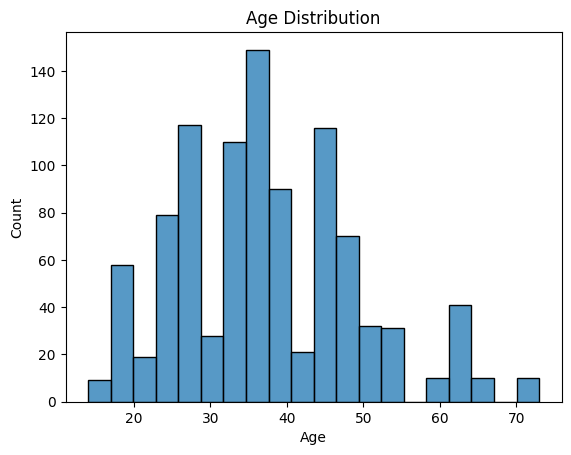

In [ ]:
plt.figure()
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()


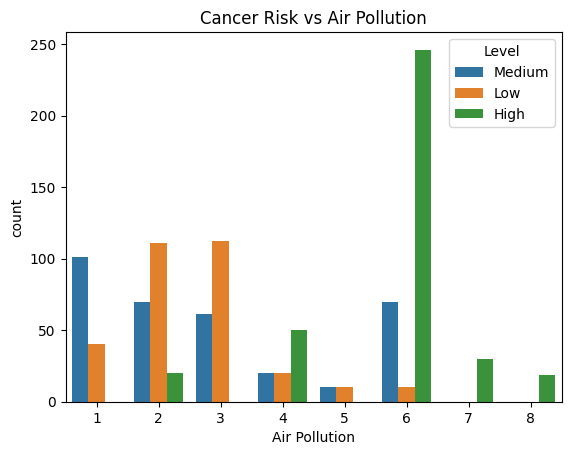

In [ ]:
plt.figure()
sns.countplot(x="Air Pollution", hue="Level", data=df)
plt.title("Cancer Risk vs Air Pollution")
plt.show()


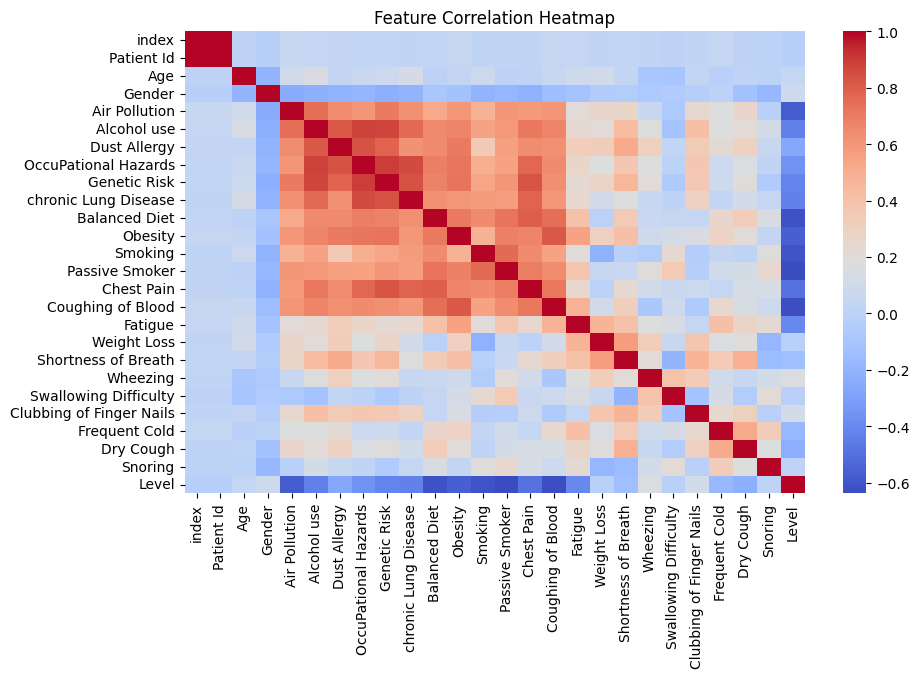

In [ ]:
encoded_df = df.copy()

le = LabelEncoder()
for col in encoded_df.columns:
    if encoded_df[col].dtype == "object":
        encoded_df[col] = le.fit_transform(encoded_df[col])

plt.figure(figsize=(10,6))
sns.heatmap(encoded_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# **Preprocessing**

In [ ]:
X = df.drop("Level", axis=1)
y = df["Level"]

# Encode categorical features
X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == "object":
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Encode target
y_encoded = LabelEncoder().fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)


# **Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        63

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



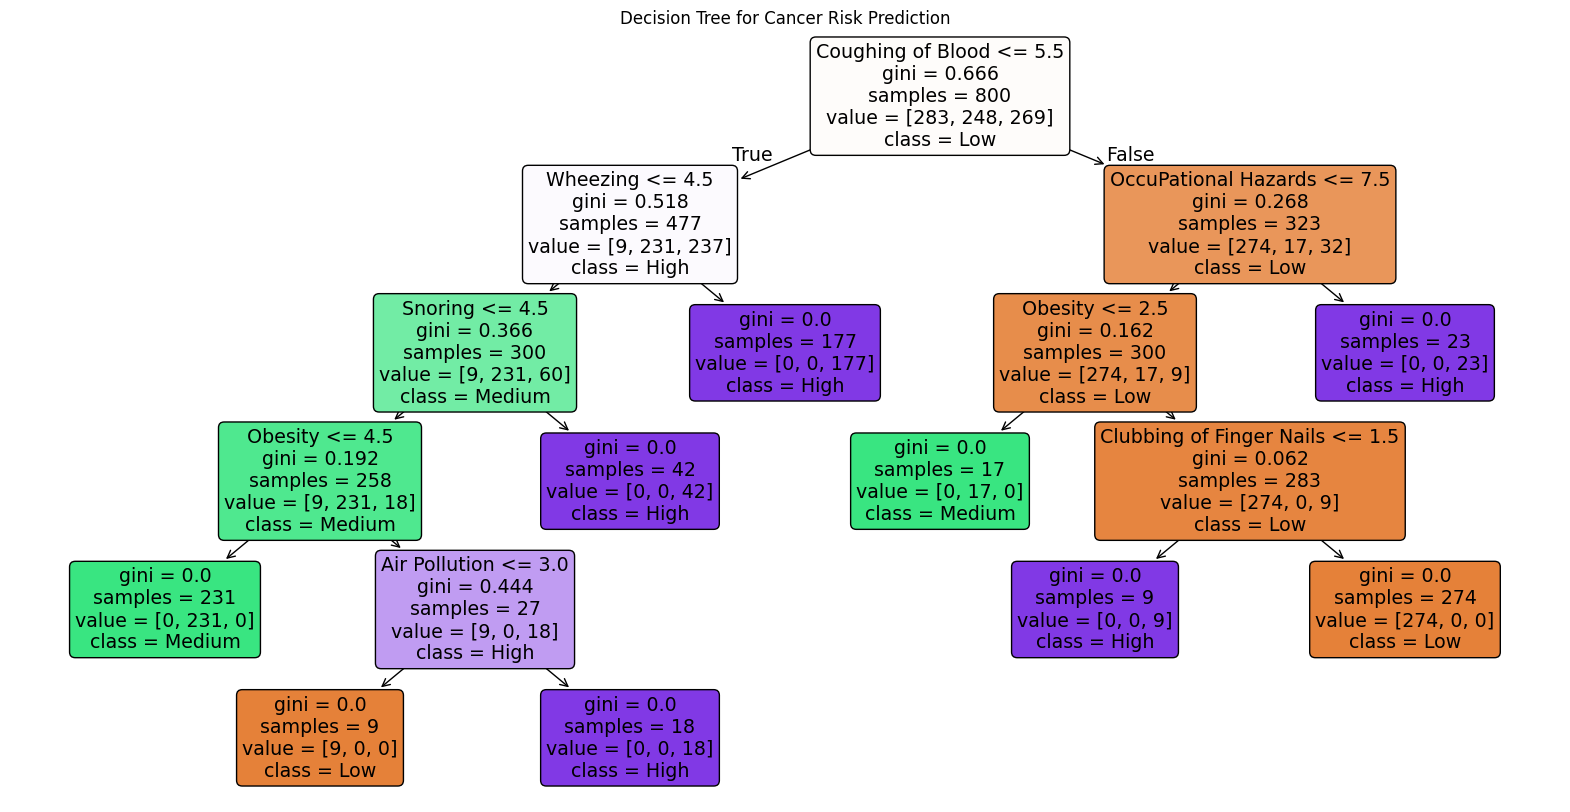

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X_encoded.columns,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Cancer Risk Prediction")
plt.show()

# **Confusion Matrix**

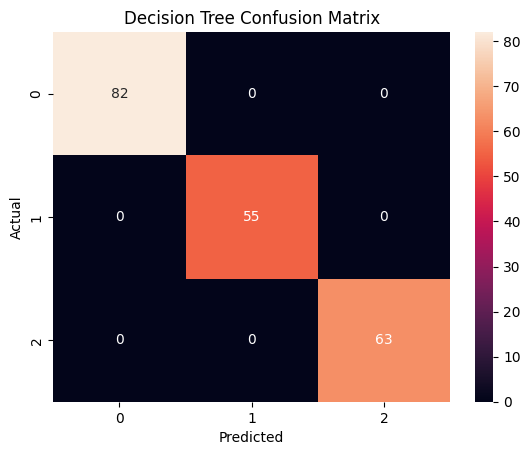

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# **Clustering**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df[["Age", "Air Pollution", "Smoking", "Cluster"]].head()


,Age,Air Pollution,Smoking,Cluster
0,33,2,3,0
1,17,3,2,0
2,35,4,2,2
3,37,7,7,1
4,46,6,8,1


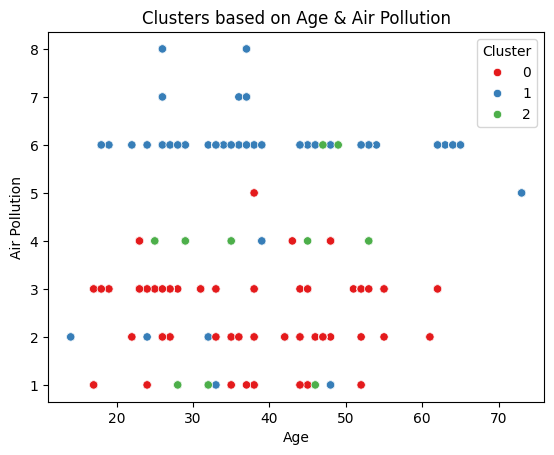

In [ ]:
plt.figure()
sns.scatterplot(
    x=df["Age"],
    y=df["Air Pollution"],
    hue=df["Cluster"],
    palette="Set1"
)
plt.title("Clusters based on Age & Air Pollution")
plt.show()


In [ ]:
df.drop(columns=["index", "Patient Id", "Level"], errors='ignore').groupby("Cluster").mean()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
Cluster,,,,,,,,,,,,,,,,,,,,,
0,35.734831,1.505618,2.364045,1.910112,3.303371,2.775281,2.501124,2.838202,2.685393,2.732584,...,2.997753,2.934831,3.177528,2.842697,3.435955,4.060674,2.757303,3.004494,2.988764,2.826966
1,38.378022,1.259341,5.358242,6.995604,6.736264,6.824176,6.652747,6.103297,5.925275,5.931868,...,6.384615,4.175824,4.090110,4.692308,4.171429,3.843956,4.782418,3.448352,4.006593,3.028571
2,38.100000,1.590000,3.500000,5.300000,6.300000,5.000000,4.400000,3.400000,6.000000,5.500000,...,6.200000,6.500000,5.800000,8.400000,3.500000,1.900000,5.200000,6.300000,7.000000,2.900000
